In [1]:
!pip list

Package                            Version
---------------------------------- -------------------
absl-py                            1.4.0
accelerate                         1.1.1
aiohappyeyeballs                   2.4.4
aiohttp                            3.11.9
aiosignal                          1.3.1
alabaster                          1.0.0
albucore                           0.0.19
albumentations                     1.4.20
altair                             4.2.2
annotated-types                    0.7.0
anyio                              3.7.1
argon2-cffi                        23.1.0
argon2-cffi-bindings               21.2.0
array_record                       0.5.1
arviz                              0.20.0
astropy                            6.1.7
astropy-iers-data                  0.2024.12.2.0.35.34
astunparse                         1.6.3
async-timeout                      4.0.3
atpublic                           4.1.0
attrs                              24.2.0
audioread           

In [2]:
import jax.numpy as jnp


# JAX

https://jax.readthedocs.io/en/latest/installation.html

In [3]:
!pip install -U jax  # nie ma potrzeby instalacji na colab

In [4]:
import numpy as np

In [5]:
import jax

In [6]:
import jax.numpy as jnp

## Operacja na tablicach


## Tworzenie tablic

In [7]:
np_array = np.array(range(10))

In [8]:
j_array = jnp.array(range(10))

In [9]:
type(j_array)

jaxlib.xla_extension.ArrayImpl

In [10]:
jnp.zeros((3, 3)) + 10

Array([[10., 10., 10.],
       [10., 10., 10.],
       [10., 10., 10.]], dtype=float32)

In [11]:
jnp.ones((3, 3))

Array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)

In [12]:
lin = jnp.linspace(0, 10, 10)
lin

Array([ 0.       ,  1.1111112,  2.2222223,  3.3333335,  4.4444447,
        5.555556 ,  6.666667 ,  7.777778 ,  8.888889 , 10.       ],      dtype=float32)

### Tablice losowe

In [13]:
random_key = jax.random.PRNGKey(42)  # 42 to jest seed ziarno do tworzenia liczbe pseudolosowych

In [14]:
rand = jax.random.normal(random_key, (30, 30))
rand.std()

Array(0.97585773, dtype=float32)

## Zadanie: utworzyć dwa wektory losowe x, y, rozkład normalny, kazdy wektor 100 wierszy i 1 kolumnę, policzyć iloczyn wektorowy

In [15]:
x = 1
y = 1
z = x * y
z

1

In [16]:
x = jax.random.normal(random_key, (100, 1))
y = jax.random.normal(random_key, (100, 1))
z = jnp.dot(x.T, y)
z

Array([[103.974236]], dtype=float32)

In [17]:
(x * y).sum()

Array(103.97421, dtype=float32)

## Funkcje w jax

In [18]:
x[0, 0]

Array(0.48043525, dtype=float32)

In [19]:
import math

In [20]:
math.exp(0.48043525)

1.6167779516752971

In [21]:
# jnp.exp(x), jnp.sin(x)

## Liczenie pochodnych

In [22]:
from jax import grad

In [23]:
def square(x):
  return x * x

square(3), 2 * 3  # wartość pochodnej, która wynosi 2 * x

(9, 6)

In [24]:
dsquare_dx = grad(square)
dsquare_dx(3.0)

Array(6., dtype=float32, weak_type=True)

In [25]:
ds_2quare_dx = grad(dsquare_dx)

In [26]:
ds_2quare_dx(3.0)

Array(2., dtype=float32, weak_type=True)

# Kompilacja jit

In [27]:
from jax import jit  # kompilowanie funkcji

In [28]:
@jit
def dot_jit(x, y):
  return jnp.dot(x, y)

In [29]:
def dot_normal(x, y):
  return np.dot(x, y)

In [30]:
%timeit dot_jit(x.T, y)

The slowest run took 5.33 times longer than the fastest. This could mean that an intermediate result is being cached.
130 µs ± 54.6 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [31]:
%timeit dot_normal(x.T, y)

46.4 µs ± 916 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [32]:
z = jax.random.normal(random_key, (1000000, ))


In [33]:
prawd_logistyczne = 1/(1 + jnp.exp(-z))

## Zadanie: korzystając z `grad` w jax policzyć pochodną fukncji logistycznej

In [34]:
def logistyczna(x):
  return 1/(1 + jnp.exp(-x))

In [41]:
df_dx = grad(sigmoid)

In [42]:
sigmoid(0.0), sigmoid(3.0), sigmoid(-3.0)

(Array(0.5, dtype=float32, weak_type=True),
 Array(0.95257413, dtype=float32, weak_type=True),
 Array(0.04742587, dtype=float32, weak_type=True))

In [43]:
df_dx(0.0), df_dx(3.0), df_dx(-3.0)

(Array(0.25, dtype=float32, weak_type=True),
 Array(0.04517666, dtype=float32, weak_type=True),
 Array(0.04517666, dtype=float32, weak_type=True))

In [44]:
sigmoid(0.0) * (1 - sigmoid(3.0))

Array(0.02371293, dtype=float32, weak_type=True)

In [45]:
import matplotlib.pyplot as plt


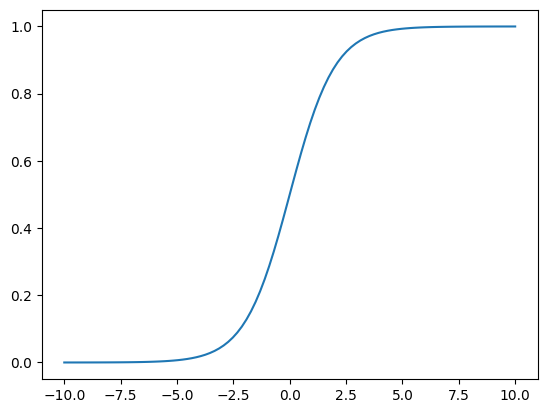

In [46]:
plt.plot(np.linspace(-10, 10, 100), sigmoid(np.linspace(-10, 10, 100)))